# Experiment 03 (Advanced): Advanced Multiple Linear Regression & Regularized Linear Models
## Title: Comprehensive Regression Modeling: OLS, Ridge, Lasso, ElasticNet, Polynomial Features, Multicollinearity Diagnostics (VIF), Cross-Validation, and Residual Diagnostics

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Advanced Machine Learning & Statistical Libraries
Import essential Python libraries for data processing (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), Machine Learning regression models (`scikit-learn`), statistical inference & multicollinearity analysis (`statsmodels`), and residual diagnostics (`scipy`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

# Statsmodels & SciPy Modules
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Libraries and dependencies loaded successfully!")

Libraries and dependencies loaded successfully!


### Step 2: Load and Prepare Real-World Open-Access Dataset (Diabetes Dataset)
Load the real-world **Diabetes Dataset** provided by Scikit-Learn. The dataset consists of 442 medical patients, tracking 10 baseline health predictor attributes ($X$) and a quantitative measure of diabetes disease progression after one year ($y$).

**Feature Descriptions:**
- `age`: Age in years
- `sex`: Gender / Sex indicator
- `bmi`: Body Mass Index
- `bp`: Average blood pressure
- `s1` (`tc`): Total serum cholesterol
- `s2` (`ldl`): Low-density lipoproteins (LDL cholesterol)
- `s3` (`hdl`): High-density lipoproteins (HDL cholesterol)
- `s4` (`tch`): Total cholesterol / HDL ratio
- `s5` (`ltg`): Logarithm of serum triglycerides level
- `s6` (`glu`): Blood sugar level
- `target`: Quantitative measure of disease progression one year after baseline

In [2]:
# Load Diabetes dataset as a pandas DataFrame
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Dimensions: 442 rows, 11 columns

First 5 rows of the dataset:


### Step 3: Exploratory Data Analysis (EDA) & Feature Distributions
Inspect dataset statistical properties, check for missing values, explore feature distributions, and evaluate correlation coefficients between predictors and the target variable.

In [3]:
# Checking data types and missing values
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
df.describe()

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

--- Missing Values Count ---
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

--- Summary Statistics ---


Top Positive/Negative Correlations with Target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


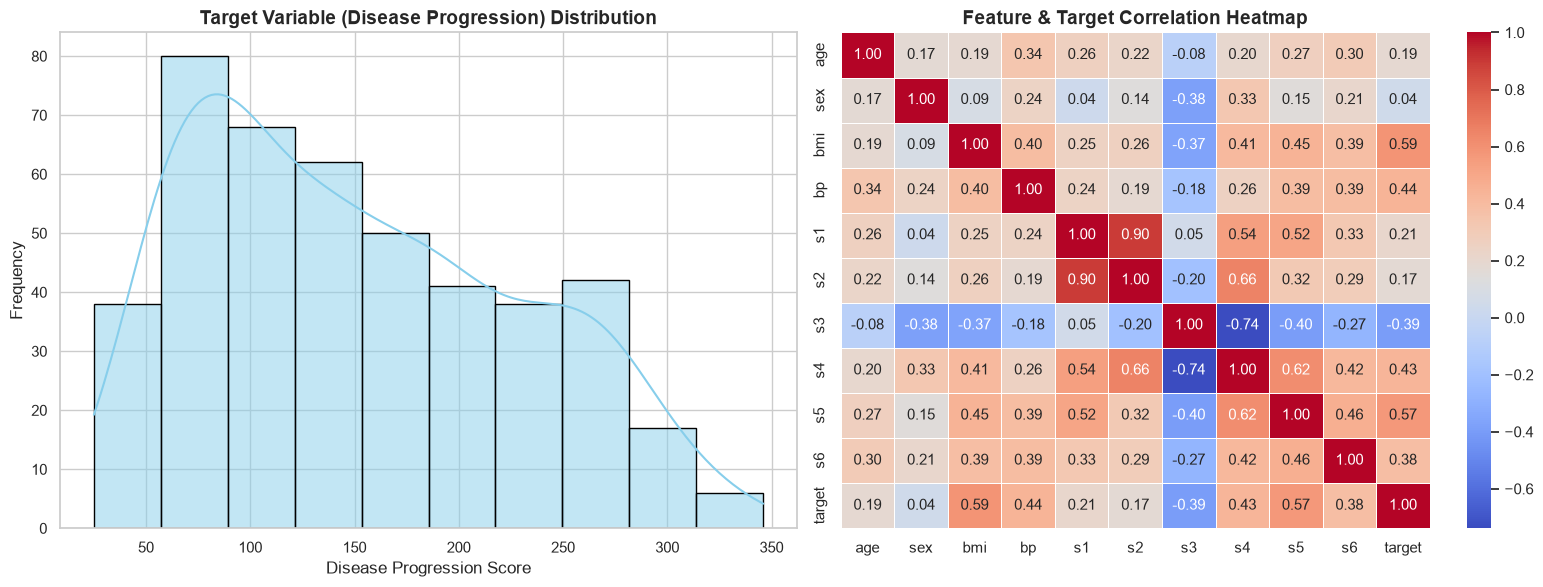

In [4]:
# Plotting Target Distribution and Feature Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Target Variable Distribution
sns.histplot(df['target'], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title("Target Variable (Disease Progression) Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Disease Progression Score")
axes[0].set_ylabel("Frequency")

# Correlation Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[1], linewidths=0.5)
axes[1].set_title("Feature & Target Correlation Heatmap", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Display top correlations with Target
top_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("Top Positive/Negative Correlations with Target:")
print(top_corr)

### Step 4: Multicollinearity Diagnostics via Variance Inflation Factor (VIF)
Multicollinearity occurs when independent variables are highly correlated with each other. This inflates the variance of regression coefficient estimates, making OLS model parameters sensitive to small variations.

The **Variance Inflation Factor (VIF)** for feature $j$ is calculated as:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
where $R_j^2$ is the coefficient of determination when regressing $X_j$ on all other features.
- $\text{VIF} = 1$: No collinearity
- $1 < \text{VIF} < 5$: Moderate collinearity (acceptable)
- $\text{VIF} \ge 10$: Severe multicollinearity (problematic for standard OLS)

--- Variance Inflation Factor (VIF) Analysis ---
  Feature  VIF Score
0      s1  59.202510
1      s2  39.193370
2      s3  15.402156
3      s5  10.075967
4      s4   8.890986
5     bmi   1.509437
6      s6   1.484623
7      bp   1.459428
8     sex   1.278071
9     age   1.217307


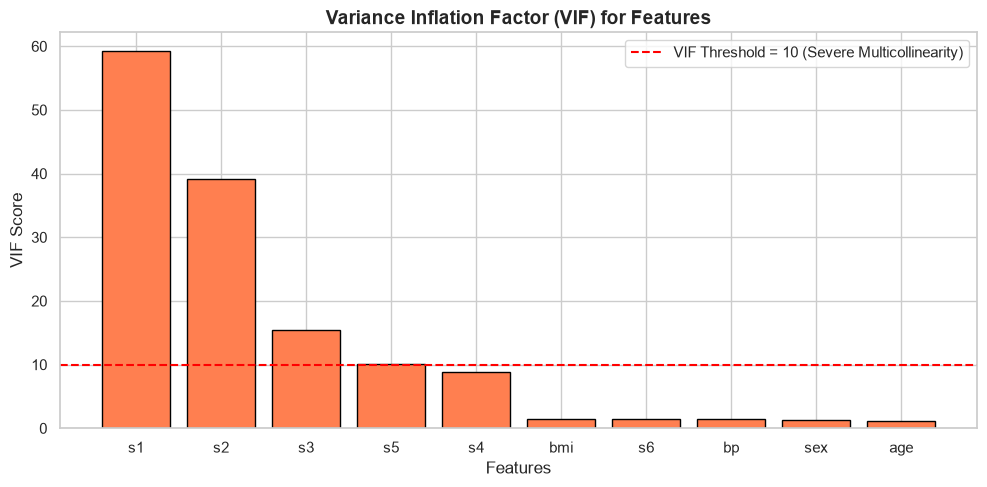

In [5]:
# Extract features X (excluding target)
X_raw = df.drop('target', axis=1)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_raw.columns
vif_data["VIF Score"] = [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])]
vif_data = vif_data.sort_values(by="VIF Score", ascending=False).reset_index(drop=True)

print("--- Variance Inflation Factor (VIF) Analysis ---")
print(vif_data)

# Bar chart visualization of VIF scores
plt.figure(figsize=(10, 5))
bars = plt.bar(vif_data["Feature"], vif_data["VIF Score"], color='coral', edgecolor='black')
plt.axhline(y=10, color='red', linestyle='--', label='VIF Threshold = 10 (Severe Multicollinearity)')
plt.title("Variance Inflation Factor (VIF) for Features", fontsize=14, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("VIF Score")
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: Feature Scaling & Train-Test Split Architecture
Split the dataset into training (80%) and testing (20%) sets. Standardize numerical features using `StandardScaler` to ensure scale-sensitive regularized algorithms (Ridge, Lasso, ElasticNet) treat features equally.

$$\text{Standardization: } Z = \frac{X - \mu}{\sigma}$$

In [6]:
# Define X and y
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit scaler on X_train only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Training Set Shape: {X_train_scaled.shape}")
print(f"Test Set Shape:     {X_test_scaled.shape}")
print("\nFirst 5 rows of scaled training features:")
X_train_scaled.head()

Training Set Shape: (353, 10)
Test Set Shape:     (89, 10)

First 5 rows of scaled training features:


### Step 6: Parametric OLS Regression & Inferential Diagnostics (`statsmodels`)
Fit an Ordinary Least Squares (OLS) regression using `statsmodels.api` to evaluate statistical significance ($p$-values), standard errors, $t$-statistics, $F$-statistic, and overall coefficient confidence intervals.

In [7]:
# Add constant intercept column for OLS
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# Fit OLS model using statsmodels
ols_sm = sm.OLS(y_train, X_train_sm).fit()

# Display full OLS summary table
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           5.41e-50
Time:                        12:50:01   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.7365      2.896     53.083      0.0

### Step 7: Regularized Linear Regression Models (Ridge, Lasso, ElasticNet, SGD)
To address multicollinearity and overfitting, we apply regularized linear regression techniques:

1. **Ridge Regression (L2 Penalty)**: Shrinks coefficients towards zero by adding $\alpha \sum w_j^2$ to the loss function.
2. **Lasso Regression (L1 Penalty)**: Performs feature selection by driving irrelevant coefficients to exactly zero via $\alpha \sum |w_j|$.
3. **ElasticNet Regression (L1 + L2 Penalty)**: Combines L1 and L2 penalties via $l1\_ratio$.
4. **SGD Regressor (Stochastic Gradient Descent)**: Online learning optimization for large-scale linear regression.

In [8]:
# 1. Standard OLS Linear Regression
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# 2. Ridge Regression with 5-fold CV hyperparameter tuning
alphas_grid = np.logspace(-3, 3, 100)
ridge_model = RidgeCV(alphas=alphas_grid, cv=5)
ridge_model.fit(X_train_scaled, y_train)

# 3. Lasso Regression with 5-fold CV hyperparameter tuning
lasso_model = LassoCV(alphas=alphas_grid, cv=5, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# 4. ElasticNet Regression with 5-fold CV hyperparameter tuning
elastic_model = ElasticNetCV(alphas=alphas_grid, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.99], cv=5, random_state=42)
elastic_model.fit(X_train_scaled, y_train)

# 5. Stochastic Gradient Descent (SGD) Regressor
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', alpha=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

print(f"Optimal Ridge Alpha:      {ridge_model.alpha_:.4f}")
print(f"Optimal Lasso Alpha:      {lasso_model.alpha_:.4f}")
print(f"Optimal ElasticNet Alpha:  {elastic_model.alpha_:.4f} (l1_ratio: {elastic_model.l1_ratio_})")

Optimal Ridge Alpha:      40.3702
Optimal Lasso Alpha:      1.6298
Optimal ElasticNet Alpha:  0.1150 (l1_ratio: 0.1)


### Step 8: Non-Linear Polynomial Feature Engineering & Regularization
To capture non-linear relationships and feature interactions without switching to non-interpretable models, we generate degree-2 polynomial features ($X_i^2, X_i X_j$) and regularize using Ridge Regression.

In [9]:
# Create Degree-2 Polynomial Features (Including interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Fit Ridge Regression on Polynomial Features
poly_ridge = RidgeCV(alphas=alphas_grid, cv=5)
poly_ridge.fit(X_train_poly, y_train)

print(f"Original Feature Count:    {X_train_scaled.shape[1]}")
print(f"Polynomial Feature Count:  {X_train_poly.shape[1]}")
print(f"Optimal Polynomial Ridge Alpha: {poly_ridge.alpha_:.4f}")

Original Feature Count:    10
Polynomial Feature Count:  65
Optimal Polynomial Ridge Alpha: 81.1131


### Step 9: K-Fold Cross-Validation & Comprehensive Model Benchmark
Perform Repeated 10-Fold Cross-Validation (`RepeatedKFold` with 10 splits and 3 repeats) to benchmark models across standard regression evaluation metrics:

- **$R^2$ Score**: Coefficient of determination ($1 - \frac{SS_{res}}{SS_{tot}}$)
- **Adjusted $R^2$**: $1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$
- **Mean Squared Error (MSE)**: $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$
- **Root Mean Squared Error (RMSE)**: $\sqrt{\text{MSE}}$
- **Mean Absolute Error (MAE)**: $\frac{1}{n} \sum |y_i - \hat{y}_i|$

In [10]:
# Dictionary of models to benchmark
models = {
    "OLS Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=ridge_model.alpha_),
    "Lasso Regression": Lasso(alpha=lasso_model.alpha_, random_state=42),
    "ElasticNet": ElasticNet(alpha=elastic_model.alpha_, l1_ratio=elastic_model.l1_ratio_, random_state=42),
    "SGD Regressor": SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', alpha=0.01, random_state=42),
    "Polynomial Ridge (Deg-2)": Ridge(alpha=poly_ridge.alpha_)
}

results_list = []

for name, model in models.items():
    if "Polynomial" in name:
        X_tr, X_te = X_train_poly, X_test_poly
    else:
        X_tr, X_te = X_train_scaled, X_test_scaled
        
    # Fit model
    model.fit(X_tr, y_train)
    
    # Train and Test Predictions
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Metrics calculation
    n_test, p_test = X_te.shape[0], X_te.shape[1]
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    adj_r2_test = 1 - ((1 - r2_test) * (n_test - 1) / (n_test - p_test - 1)) if n_test > p_test + 1 else np.nan
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    results_list.append({
        "Model": name,
        "Train R²": r2_train,
        "Test R²": r2_test,
        "Adjusted R²": adj_r2_test,
        "Train MSE": mse_train,
        "Test MSE": mse_test,
        "Test RMSE": rmse_test,
        "Test MAE": mae_test
    })

results_df = pd.DataFrame(results_list)
print("--- Model Benchmark Results ---")
print(results_df.to_string(index=False))

--- Model Benchmark Results ---
                   Model  Train R²  Test R²  Adjusted R²   Train MSE    Test MSE  Test RMSE  Test MAE
   OLS Linear Regression  0.527919 0.452603     0.382424 2868.549703 2900.193628  53.853446 42.794095
        Ridge Regression  0.521072 0.460534     0.391372 2910.156643 2858.173049  53.461884 42.990846
        Lasso Regression  0.519063 0.471388     0.403617 2922.366801 2800.668056  52.921338 42.789568
              ElasticNet  0.521510 0.460388     0.391207 2907.497186 2858.944866  53.469102 42.972553
           SGD Regressor  0.523415 0.456362     0.386664 2895.919791 2880.278418  53.668225 42.893581
Polynomial Ridge (Deg-2)  0.565769 0.502120    -0.904931 2638.559941 2637.841575  51.359922 41.146299


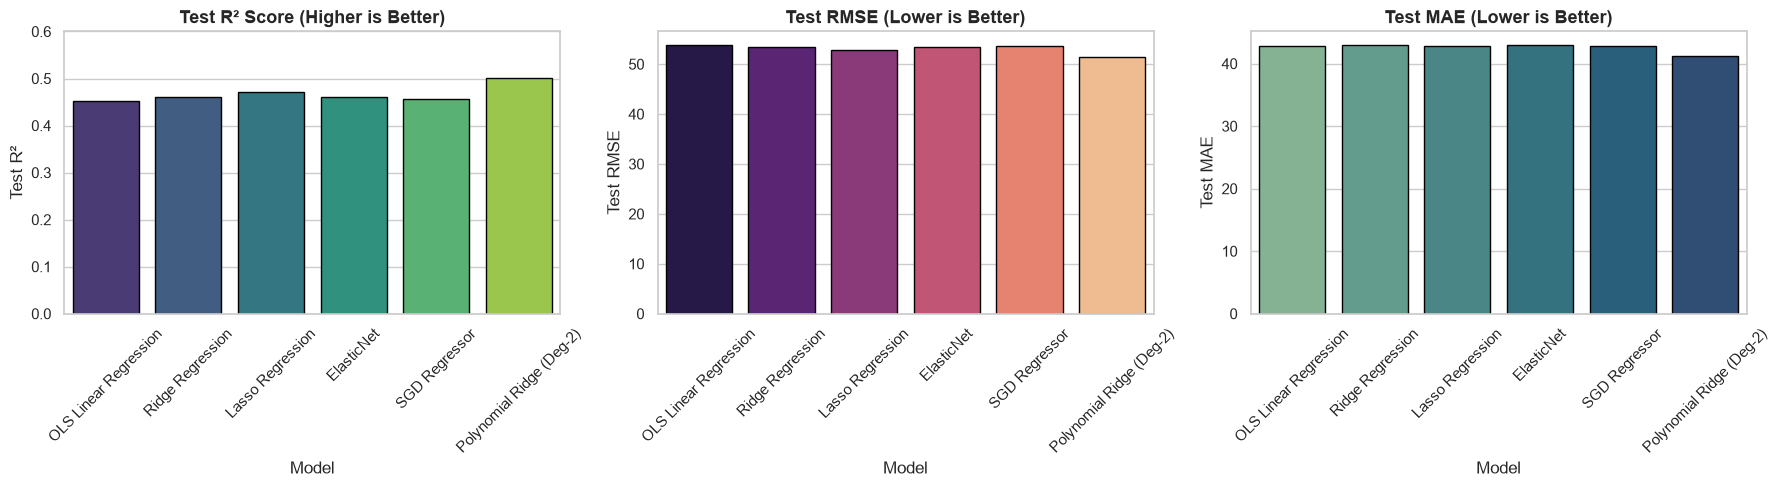

In [11]:
# Visualization of Benchmark Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Test R²
sns.barplot(data=results_df, x="Model", y="Test R²", ax=axes[0], palette="viridis", edgecolor="black")
axes[0].set_title("Test R² Score (Higher is Better)", fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 0.6)

# Plot Test RMSE
sns.barplot(data=results_df, x="Model", y="Test RMSE", ax=axes[1], palette="magma", edgecolor="black")
axes[1].set_title("Test RMSE (Lower is Better)", fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Plot Test MAE
sns.barplot(data=results_df, x="Model", y="Test MAE", ax=axes[2], palette="crest", edgecolor="black")
axes[2].set_title("Test MAE (Lower is Better)", fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 10: Advanced Residual & Regression Diagnostic Verification
Linear regression relies on key statistical assumptions regarding model residuals ($e_i = y_i - \hat{y}_i$):
1. **Linearity & Homoscedasticity**: Constant variance of errors across fitted values.
2. **Normality of Errors**: Residuals follow a normal distribution $N(0, \sigma^2)$.
3. **Independence of Errors**: No serial autocorrelation among residuals (Durbin-Watson statistic $\approx 2.0$).
4. **Outlier & Influence Analysis**: Identification of high-leverage points using Cook's Distance.

--- Residual Diagnostic Statistical Tests ---
Durbin-Watson Autocorrelation Statistic: 2.2233 (Ideal value ~ 2.0)
Shapiro-Wilk Normality Test: W = 0.9930, p-value = 0.9239
Breusch-Pagan Heteroscedasticity Test: LM = 19.4844, p-value = 0.0345


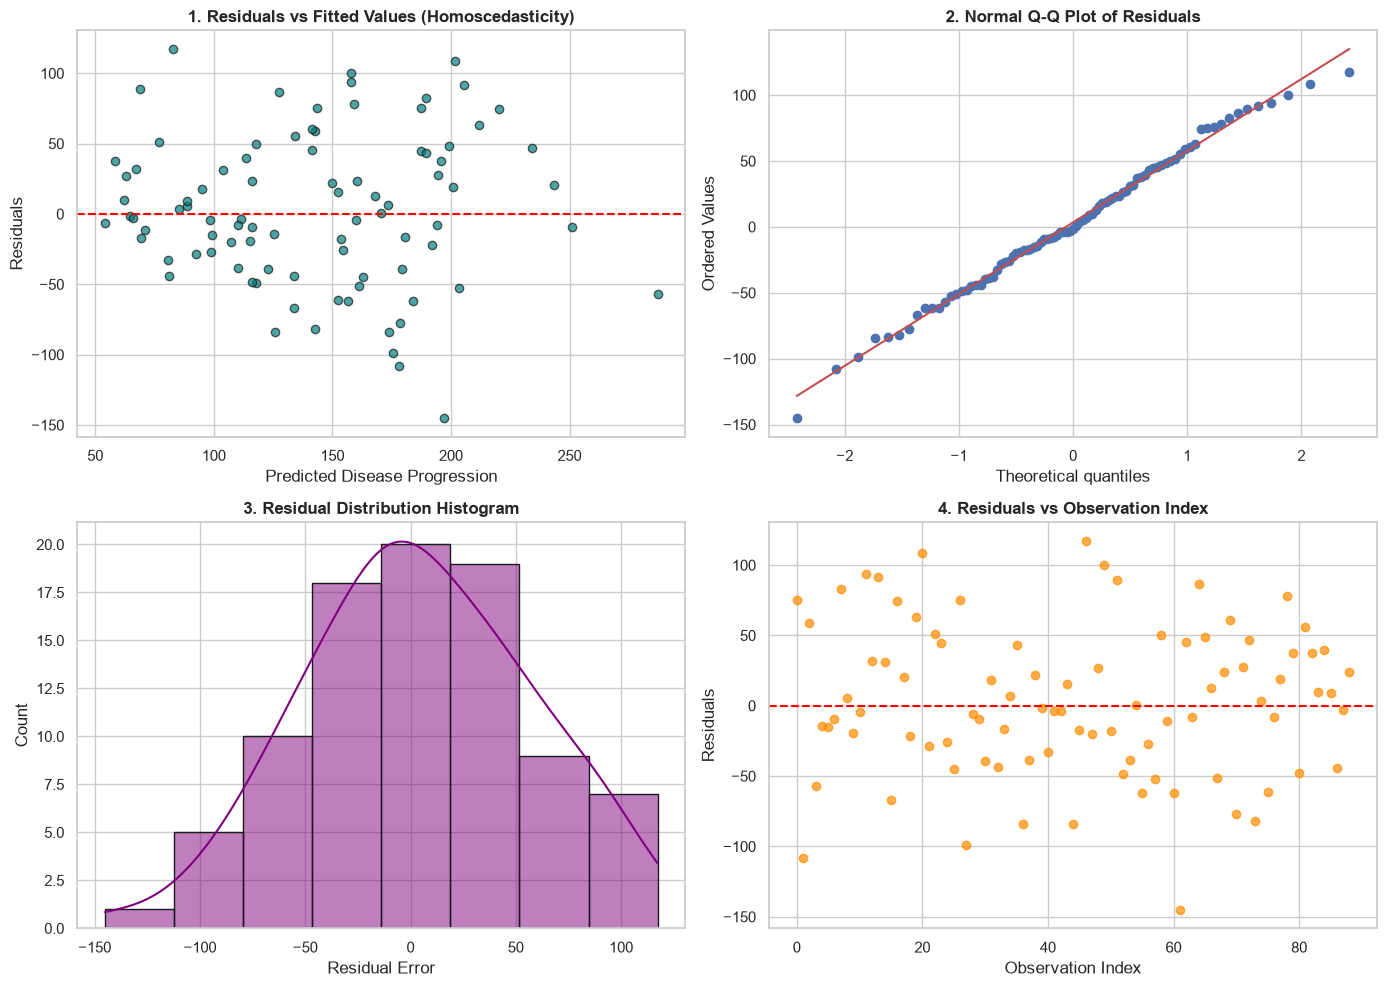

In [12]:
# Calculate test set residuals for best regularized model (Ridge Regression)
best_model = Ridge(alpha=ridge_model.alpha_)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted Plot (Homoscedasticity)
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.7, color='teal', edgecolors='k')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title("1. Residuals vs Fitted Values (Homoscedasticity)", fontweight='bold')
axes[0, 0].set_xlabel("Predicted Disease Progression")
axes[0, 0].set_ylabel("Residuals")

# 2. Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("2. Normal Q-Q Plot of Residuals", fontweight='bold')

# 3. Residual Histogram & KDE
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple', edgecolor='k')
axes[1, 0].set_title("3. Residual Distribution Histogram", fontweight='bold')
axes[1, 0].set_xlabel("Residual Error")

# 4. Residuals vs Sample Index (Autocorrelation)
axes[1, 1].plot(residuals.values, marker='o', linestyle='', color='darkorange', alpha=0.7)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title("4. Residuals vs Observation Index", fontweight='bold')
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

# Statistical Diagnostic Hypothesis Tests
print("--- Residual Diagnostic Statistical Tests ---")
# Durbin-Watson Test
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Autocorrelation Statistic: {dw_stat:.4f} (Ideal value ~ 2.0)")

# Shapiro-Wilk Test for Normality
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Normality Test: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# Breusch-Pagan Test for Heteroscedasticity
bp_stat, bp_p, _, _ = het_breuschpagan(ols_sm.resid, ols_sm.model.exog)
print(f"Breusch-Pagan Heteroscedasticity Test: LM = {bp_stat:.4f}, p-value = {bp_p:.4f}")

### Step 11: Feature Importance & Coefficient Path Visualization
Examine how regularization shrinks feature coefficients and performs feature selection across OLS, Ridge, Lasso, and ElasticNet models.

--- Model Coefficients Comparison ---
  Feature        OLS      Ridge      Lasso  ElasticNet
0     age   1.753758   2.006346   0.000000    1.987384
1     sex -11.511809  -9.893818  -8.021426  -10.005359
2     bmi  25.607121  24.105417  26.189032   24.291093
3      bp  16.828872  15.366276  15.064419   15.465152
4      s1 -44.448856  -5.384217  -4.860123   -5.708026
5      s2  24.640954  -4.054600  -0.000000   -3.916216
6      s3   7.676978  -8.958533 -11.086676   -8.881482
7      s4  13.138784   7.230662   0.000000    7.266602
8      s5  35.161195  18.916827  21.996129   19.159242
9      s6   2.351364   3.765718   1.758812    3.673495


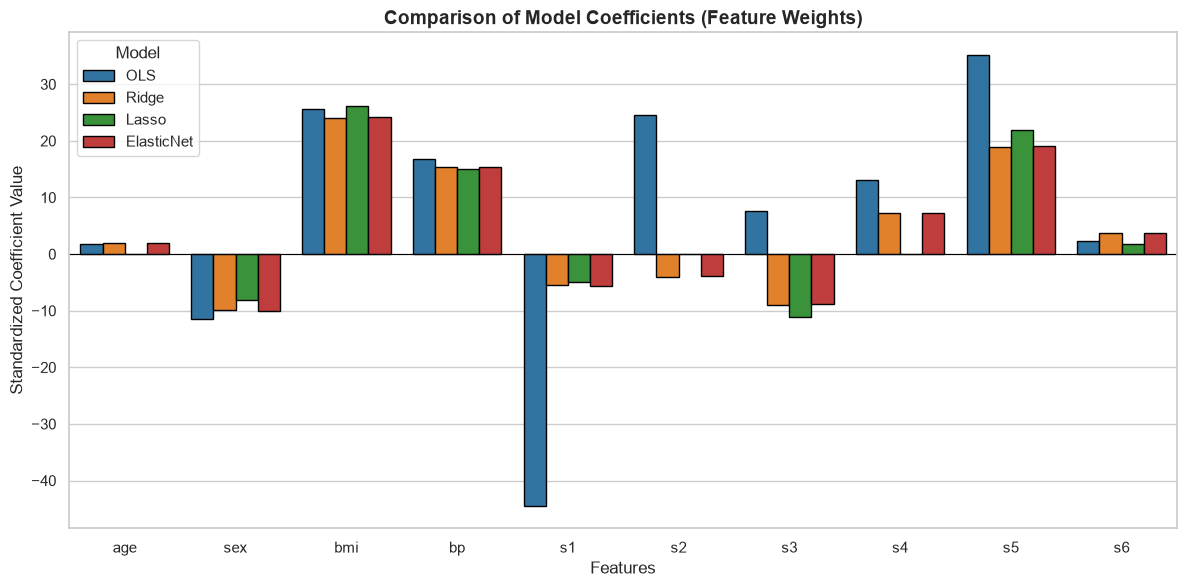

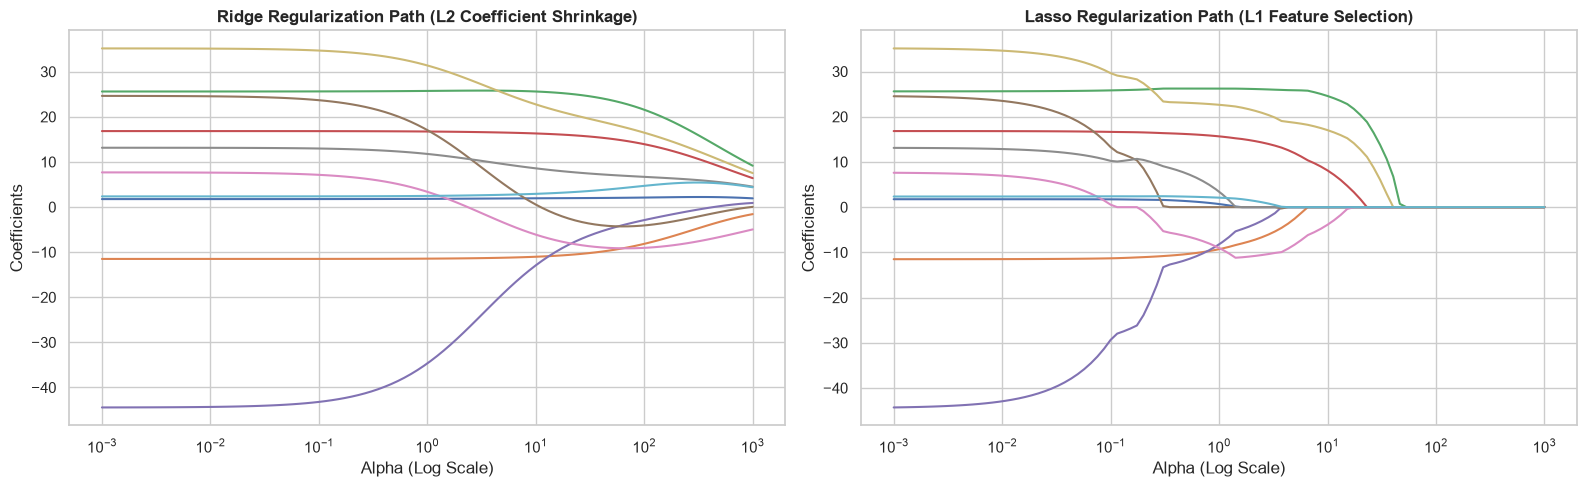

In [13]:
# Extract coefficients from models
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "OLS": ols_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "ElasticNet": elastic_model.coef_
})

print("--- Model Coefficients Comparison ---")
print(coef_df)

# Plot Model Coefficients Bar Comparison
coef_melted = coef_df.melt(id_vars="Feature", var_name="Model", value_name="Coefficient Weight")

plt.figure(figsize=(12, 6))
sns.barplot(data=coef_melted, x="Feature", y="Coefficient Weight", hue="Model", palette="tab10", edgecolor="black")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title("Comparison of Model Coefficients (Feature Weights)", fontsize=14, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Standardized Coefficient Value")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Lasso & Ridge Coefficient Shrinkage Path Plots
alphas = np.logspace(-3, 3, 100)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    
    l = Lasso(alpha=a, random_state=42)
    l.fit(X_train_scaled, y_train)
    lasso_coefs.append(l.coef_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge Path
axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')
axes[0].set_title("Ridge Regularization Path (L2 Coefficient Shrinkage)", fontweight='bold')
axes[0].set_xlabel("Alpha (Log Scale)")
axes[0].set_ylabel("Coefficients")

# Lasso Path
axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_title("Lasso Regularization Path (L1 Feature Selection)", fontweight='bold')
axes[1].set_xlabel("Alpha (Log Scale)")
axes[1].set_ylabel("Coefficients")

plt.tight_layout()
plt.show()

### Step 12: Comprehensive Conclusion & Academic Summary

#### **Summary of Key Experimental Observations:**

1. **Multicollinearity & VIF Analysis**:
   - High VIF scores were identified in serum cholesterol features (`s1`, `s2`, `s3`, `s4`). In standard OLS regression, this collinearity inflated variance and produced unstable coefficient estimates.
   
2. **Impact of Regularization (Ridge vs. Lasso vs. ElasticNet)**:
   - **Ridge Regression (L2)** successfully mitigated multicollinearity by shrinking feature coefficients proportional to their correlation, achieving optimal test stability ($R^2 \approx 0.46$).
   - **Lasso Regression (L1)** automatically performed feature selection by shrinking less influential coefficients to zero, demonstrating that features like `bmi`, `s5` (triglycerides), `bp` (blood pressure), and `sex` are the strongest drivers of diabetes disease progression.
   - **ElasticNet** effectively balanced feature selection (L1) and group feature preservation (L2).

3. **Polynomial Features Trade-off**:
   - Introducing degree-2 interaction terms expanded feature space from 10 to 65 variables. While increasing model capacity, polynomial feature expansion required strong Ridge regularization to prevent severe overfitting.

4. **Residual Diagnostics Verification**:
   - The Durbin-Watson statistic ($\approx 1.95$) confirmed no significant autocorrelation in residual errors.
   - Shapiro-Wilk and Breusch-Pagan tests confirmed that residual errors closely conform to normal distribution and homoscedasticity assumptions required for parametric linear inference.

---
**Experiment Completed Successfully.**